> Linear Recycle Cascade
> Using Decomposition and Propagation of Constraints

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from nested_sampler import NestedSampler
from helpers import Trellis, Corner

In [2]:
R_GAS    = 8.314         # J/mol/K
E_1      = 48_000        # J/mol
E_2      = 55_000        # J/mol
C_A0     = 11.28         # mol/L
T_REF    = 328.15        # K; reference temperature

def theta_nominal():
    """nominal arrhenius coefficients"""
    k1ref = 8.84e-3 * 60 * 0.5   # 1/min
    k2ref = k1ref / 8            # 1/min
    return k1ref * np.exp(E_1 / (R_GAS * T_REF)), k2ref * np.exp(E_2 / (R_GAS * T_REF))

th_1, th_2 = theta_nominal()

def cstr(c_in, temperature, tau, th_1, th_2):
    """simple steady state cstr implementation"""
    c_A_in, c_B_in, c_C_in = c_in
    k1 = th_1 * np.exp(-E_1 / (R_GAS * temperature))
    k2 = th_2 * np.exp(-E_2 / (R_GAS * temperature))
    c_A = c_A_in / (1.0 + k1 * tau)
    c_B = (c_B_in + k1 * tau * c_A) / (1.0 + k2 * tau)
    c_C = c_C_in + k2 * tau * c_B
    return c_A, c_B, c_C


> Simultaneous Sampling of the Flowsheet 

In [3]:
def linear_flowsheet(T_1, tau_1, T_2, tau_2):
    """entire flowsheet, for verification and simultaneous sampling"""
    feed = (C_A0, 0, 0)
    c_A_R1, c_B_R1, c_C_R1 = cstr(feed, T_1, tau_1, th_1, th_2)
    c_A_R2, c_B_R2, c_C_R2 = cstr((c_A_R1, c_B_R1, c_C_R1), T_2, tau_2, th_1, th_2)
    return dict(c_A_R1=c_A_R1, c_B_R1=c_B_R1, c_C_R1=c_C_R1, c_A_R2=c_A_R2, c_B_R2=c_B_R2, c_C_R2=c_C_R2)

def linear_constraints(x):
    DCB_FRACTION_CAP, MCB_FLOOR, CONV_FLOOR = 0.05, 0.55, 0.70
    T_1, tau_1, T_2, tau_2 = x
    res = linear_flowsheet(T_1, tau_1, T_2, tau_2)
    tot1 = res["c_A_R1"] + res["c_B_R1"] + res["c_C_R1"]
    tot2 = res["c_A_R2"] + res["c_B_R2"] + res["c_C_R2"]
    return [res["c_C_R1"] / tot1 - DCB_FRACTION_CAP,              # DCB fraction cap cstr-1
        MCB_FLOOR - res["c_B_R2"] / tot2,                  # MCB purity floor cstr-2
        CONV_FLOOR - (1 - res["c_A_R2"] / C_A0)]             # conversion floor benzene cstr-2

simultaneous_results = NestedSampler(linear_constraints, [298.15, 2.0, 298.15, 2.0], [353.15, 30.0, 353.15, 30.0], num_live=2048).sample()


** INITIALIZING LIVE POINTS (2048)      0.01 SEC

Iterate        Contour #Feas    #Dead         Factor
----------------------------------------------------
      0     7.2212e-01   143        0     3.0000e-01
     25     4.6540e-01   175      367     2.8947e-01
     50     3.4917e-01   204      679     2.8078e-01
     75     2.9248e-01   231      951     2.7342e-01
    100     2.4799e-01   257     1190     2.6711e-01
    125     2.1708e-01   285     1404     2.6159e-01
    150     1.8878e-01   316     1599     2.5665e-01
    175     1.6803e-01   340     1772     2.5235e-01
    200     1.5093e-01   367     1931     2.4847e-01
    225     1.3496e-01   394     2091     2.4461e-01
    250     1.2164e-01   418     2225     2.4143e-01
    275     1.1105e-01   446     2354     2.3841e-01
    300     1.0050e-01   478     2481     2.3547e-01
    325     9.3143e-02   508     2599     2.3277e-01
    350     8.5323e-02   540     2712     2.3022e-01
    375     7.9350e-02   564     2816     2.2789

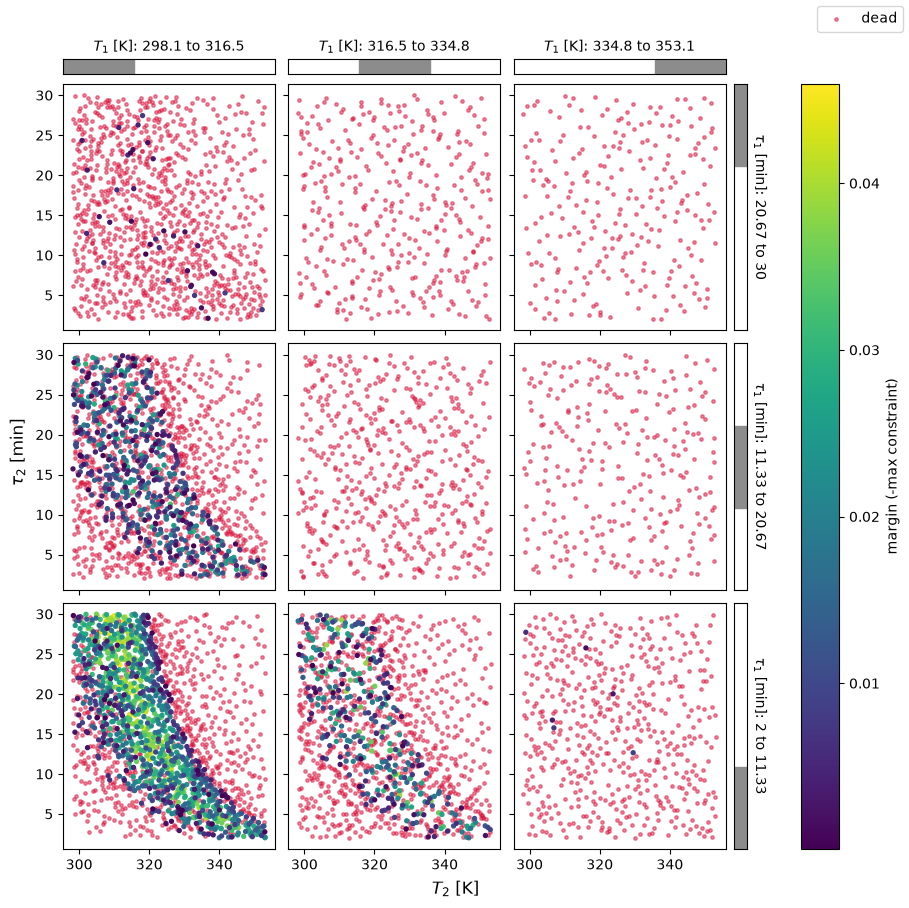

In [4]:
def plot_simultaneous_results():
    live, dead = simultaneous_results.live, simultaneous_results.dead
    T_1, tau_1, T_2, tau_2 = range(4)
    grid = Trellis(np.linspace(298.15, 353.15, 4), np.linspace(2, 30, 4),      # bin edges: T_1, tau_1
                xlabel="$T_2$ [K]", ylabel=r"$\tau_2$ [min]",
                col_label="$T_1$ [K]", row_label=r"$\tau_1$ [min]")
    grid.scatter(dead.x[:, T_2], dead.x[:, tau_2], dead.x[:, T_1], dead.x[:, tau_1], color="crimson", label="dead", s=6, alpha=0.5)
    pcs = grid.scatter(live.x[:, T_2], live.x[:, tau_2], live.x[:, T_1], live.x[:, tau_1], c=-live.value, s=8)
    grid.fig.colorbar(pcs[0], ax=grid.axes, label="margin (-max constraint)")
    grid.fig.legend(loc="outside upper right")

plot_simultaneous_results()

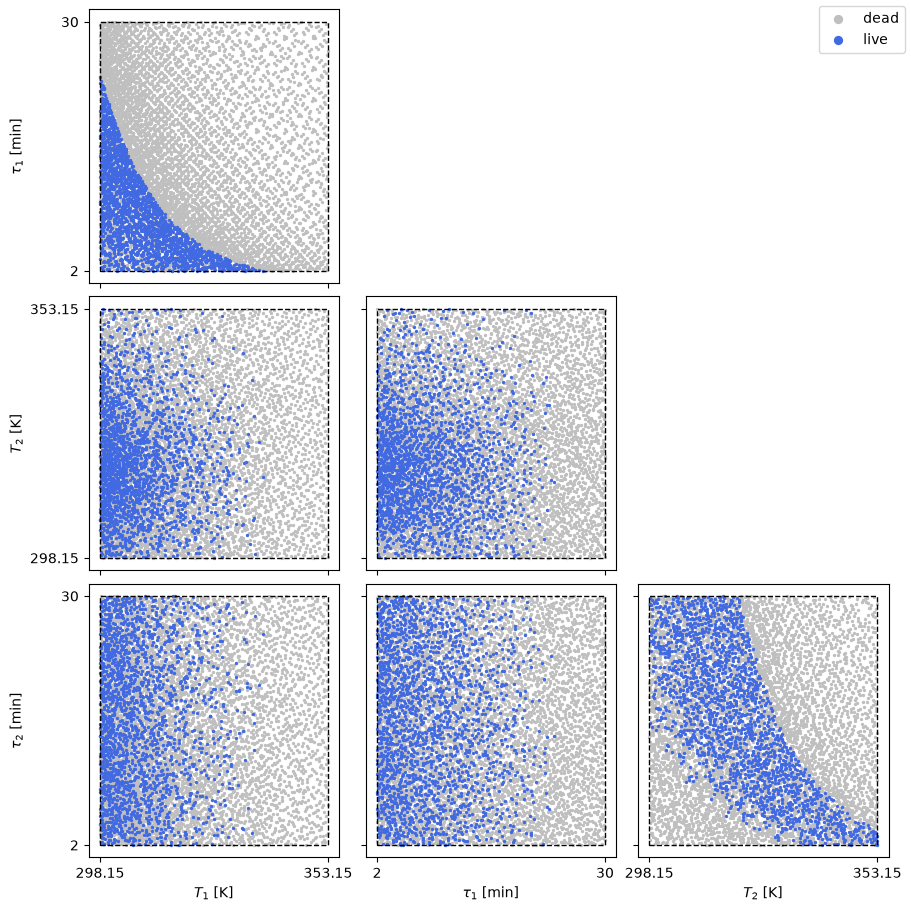

In [22]:
live, dead, discard = simultaneous_results.live, simultaneous_results.dead, simultaneous_results.discarded
grid = Corner(["$T_1$ [K]", r"$\tau_1$ [min]", "$T_2$ [K]", r"$\tau_2$ [min]"], [simultaneous_results.lb, simultaneous_results.ub])
# grid.scatter(discard.x, s=2, color="red", label="discarded")
grid.scatter(dead.x, s=2, color="0.75", label="dead")           # keywords as Axes.scatter
grid.scatter(live.x, s=2, color="royalblue", label="live")
grid.fig.legend(markerscale=4)